In [1]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from libpysal.weights import Queen
from esda.moran import Moran
from esda.getisord import G_Local
from splot.esda import moran_scatterplot
import matplotlib.patches as mpatches

In [2]:
# !pip install geodatasets

In [3]:
# adjust this line to point towards root of the project directory.
# this file is inside /src, so using '..' to move 1 step up towards the root directory
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [4]:
df = gpd.read_file('data/Fire/DL_FIRE_M-C61_660433/fire_archive_M-C61_660433.shp')

In [5]:
df.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,27.5921,87.5385,306.2,1.1,1.1,2000-11-01,0500,Terra,MODIS,55,6.03,292.1,6.2,D,0,POINT (87.5385 27.5921)
1,29.1006,81.9170,330.6,1.3,1.1,2000-11-06,0518,Terra,MODIS,87,6.03,293.7,43.0,D,0,POINT (81.917 29.1006)
2,30.0881,81.3358,308.7,1.8,1.3,2000-11-07,0601,Terra,MODIS,58,6.03,291.2,21.1,D,0,POINT (81.3358 30.0881)
3,30.0841,81.3570,306.0,1.9,1.3,2000-11-07,0601,Terra,MODIS,37,6.03,287.4,17.1,D,0,POINT (81.357 30.0841)
4,30.1060,81.9647,315.0,2.1,1.4,2000-11-08,0506,Terra,MODIS,64,6.03,282.6,41.6,D,0,POINT (81.9647 30.106)


In [6]:
# merge date and time to single column
df['datetime'] = pd.to_datetime(
  df["ACQ_DATE"].astype(str) + " " + df['ACQ_TIME'].astype(str).str.zfill(4),
  format='%Y-%m-%d %H%M'
).drop(
  columns=["ACQ_DATE", "ACQ_TIME", "INSTRUMENT"]
)

df.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,datetime
0,27.5921,87.5385,306.2,1.1,1.1,2000-11-01,0500,Terra,MODIS,55,6.03,292.1,6.2,D,0,POINT (87.5385 27.5921),2000-11-01 05:00:00
1,29.1006,81.9170,330.6,1.3,1.1,2000-11-06,0518,Terra,MODIS,87,6.03,293.7,43.0,D,0,POINT (81.917 29.1006),2000-11-06 05:18:00
2,30.0881,81.3358,308.7,1.8,1.3,2000-11-07,0601,Terra,MODIS,58,6.03,291.2,21.1,D,0,POINT (81.3358 30.0881),2000-11-07 06:01:00
3,30.0841,81.3570,306.0,1.9,1.3,2000-11-07,0601,Terra,MODIS,37,6.03,287.4,17.1,D,0,POINT (81.357 30.0841),2000-11-07 06:01:00
4,30.1060,81.9647,315.0,2.1,1.4,2000-11-08,0506,Terra,MODIS,64,6.03,282.6,41.6,D,0,POINT (81.9647 30.106),2000-11-08 05:06:00


In [7]:
df.sort_values('datetime', ascending=True)

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,datetime
0,27.5921,87.5385,306.2,1.1,1.1,2000-11-01,0500,Terra,MODIS,55,6.03,292.1,6.2,D,0,POINT (87.5385 27.5921),2000-11-01 05:00:00
1,29.1006,81.9170,330.6,1.3,1.1,2000-11-06,0518,Terra,MODIS,87,6.03,293.7,43.0,D,0,POINT (81.917 29.1006),2000-11-06 05:18:00
2,30.0881,81.3358,308.7,1.8,1.3,2000-11-07,0601,Terra,MODIS,58,6.03,291.2,21.1,D,0,POINT (81.3358 30.0881),2000-11-07 06:01:00
3,30.0841,81.3570,306.0,1.9,1.3,2000-11-07,0601,Terra,MODIS,37,6.03,287.4,17.1,D,0,POINT (81.357 30.0841),2000-11-07 06:01:00
4,30.1060,81.9647,315.0,2.1,1.4,2000-11-08,0506,Terra,MODIS,64,6.03,282.6,41.6,D,0,POINT (81.9647 30.106),2000-11-08 05:06:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79048,29.3110,81.8124,323.8,2.4,1.5,2025-06-14,0926,Aqua,MODIS,25,61.03,295.1,42.8,D,0,POINT (81.8124 29.311),2025-06-14 09:26:00
79049,29.9688,81.3453,326.7,1.0,1.0,2025-06-21,0904,Aqua,MODIS,75,61.03,304.7,18.3,D,0,POINT (81.3453 29.9688),2025-06-21 09:04:00
79050,29.9674,81.3348,318.2,1.0,1.0,2025-06-21,0904,Aqua,MODIS,43,61.03,299.4,8.8,D,0,POINT (81.3348 29.9674),2025-06-21 09:04:00
79051,27.4277,85.0329,312.3,1.1,1.0,2025-06-24,0403,Terra,MODIS,57,61.03,293.7,6.6,D,0,POINT (85.0329 27.4277),2025-06-24 04:03:00


In [8]:
wildfires = df

In [9]:
# dataset containing territorial areas and boundaries of Nepal
states_full = gpd.read_file('data/gadm41_NPL.gpkg', layer='ADM_ADM_3')

In [10]:
states_full.head()

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
0,NPL.1.1.1_1,NPL,Nepal,NPL.1_1,Central,मध्यमाञ्चल विकास क्षेत्र,NPL.1.1_1,Bagmati,NA,Bhaktapur,Bhadgaon| Khwopa|Bhaktapur Jilla,NA,Jilla,District,NA,NP.MM.BK,"MULTIPOLYGON (((85.4064 27.63235, 85.3987 27.6..."
1,NPL.1.1.2_1,NPL,Nepal,NPL.1_1,Central,मध्यमाञ्चल विकास क्षेत्र,NPL.1.1_1,Bagmati,NA,Dhading,NA,NA,Jilla,District,NA,NP.MM.DH,"MULTIPOLYGON (((84.90819 27.69722, 84.9026 27...."
2,NPL.1.1.3_1,NPL,Nepal,NPL.1_1,Central,मध्यमाञ्चल विकास क्षेत्र,NPL.1.1_1,Bagmati,NA,Kathmandu,KTM,NA,Jilla,District,NA,NP.MM.KT,"MULTIPOLYGON (((85.28735 27.58574, 85.28586 27..."
3,NPL.1.1.4_1,NPL,Nepal,NPL.1_1,Central,मध्यमाञ्चल विकास क्षेत्र,NPL.1.1_1,Bagmati,NA,Kavrepalanchok,"Kavrepalanchowk, Kavreplanchok",NA,Jilla,District,NA,NP.MM.KV,"MULTIPOLYGON (((85.69758 27.36454, 85.69907 27..."
4,NPL.1.1.5_1,NPL,Nepal,NPL.1_1,Central,मध्यमाञ्चल विकास क्षेत्र,NPL.1.1_1,Bagmati,NA,Lalitpur,Patan,NA,Jilla,District,NA,NP.MM.LL,"MULTIPOLYGON (((85.41771 27.43488, 85.41286 27..."


In [11]:
states = states_full.drop(columns=['GID_0', 'COUNTRY', 'CC_3', 'NL_NAME_1', 'NL_NAME_2', 'NL_NAME_3', 'VARNAME_3', 'TYPE_3']).rename(columns={
    'GID_1': 'PROVINCE_CODE',
    'GID_2': 'DISTRICT_CODE',
    'GID_3': 'STATE_CODE',
    'NAME_1': 'PROVINCE_NAME',
    'NAME_2': 'DISTRICT_NAME',
    'NAME_3': 'STATE_NAME',
    'ENGTYPE_3': 'LAYER_TYPE',
    'HASC_3': 'SUBDIVISION_CODE',
})

states.head()

,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry
0,NPL.1.1.1_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Bhaktapur,District,NP.MM.BK,"MULTIPOLYGON (((85.4064 27.63235, 85.3987 27.6..."
1,NPL.1.1.2_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Dhading,District,NP.MM.DH,"MULTIPOLYGON (((84.90819 27.69722, 84.9026 27...."
2,NPL.1.1.3_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kathmandu,District,NP.MM.KT,"MULTIPOLYGON (((85.28735 27.58574, 85.28586 27..."
3,NPL.1.1.4_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kavrepalanchok,District,NP.MM.KV,"MULTIPOLYGON (((85.69758 27.36454, 85.69907 27..."
4,NPL.1.1.5_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Lalitpur,District,NP.MM.LL,"MULTIPOLYGON (((85.41771 27.43488, 85.41286 27..."


In [12]:
states.crs == wildfires.crs

True

In [13]:
states.to_file('output/states.gpkg', driver='GPKG')

In [14]:
fire_with_state = gpd.sjoin(wildfires, states, how='left', predicate='within').drop(columns=['SCAN', 'TRACK', 'SATELLITE', 'INSTRUMENT', 'VERSION', 'DAYNIGHT'])

In [15]:
fire_with_state.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,TYPE,geometry,datetime,index_right,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE
0,27.5921,87.5385,306.2,2000-11-01,0500,55,292.1,6.2,0,POINT (87.5385 27.5921),2000-11-01 05:00:00,28.0,NPL.2.2.4_1,NPL.2_1,East,NPL.2.2_1,Mechi,Taplejung,District,NP.PW.TP
1,29.1006,81.9170,330.6,2000-11-06,0518,87,293.7,43.0,0,POINT (81.917 29.1006),2000-11-06 05:18:00,52.0,NPL.4.2.4_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Kalikot,District,NP.MP.KK
2,30.0881,81.3358,308.7,2000-11-07,0601,58,291.2,21.1,0,POINT (81.3358 30.0881),2000-11-07 06:01:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU
3,30.0841,81.3570,306.0,2000-11-07,0601,37,287.4,17.1,0,POINT (81.357 30.0841),2000-11-07 06:01:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU
4,30.1060,81.9647,315.0,2000-11-08,0506,64,282.6,41.6,0,POINT (81.9647 30.106),2000-11-08 05:06:00,50.0,NPL.4.2.2_1,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU


## Preprocessing

In [16]:
fire_with_state.drop(columns=['TYPE'], inplace=True)

In [17]:
fire_with_state.columns

Index(['LATITUDE', 'LONGITUDE', 'BRIGHTNESS', 'ACQ_DATE', 'ACQ_TIME',
       'CONFIDENCE', 'BRIGHT_T31', 'FRP', 'geometry', 'datetime',
       'index_right', 'STATE_CODE', 'PROVINCE_CODE', 'PROVINCE_NAME',
       'DISTRICT_CODE', 'DISTRICT_NAME', 'STATE_NAME', 'LAYER_TYPE',
       'SUBDIVISION_CODE'],
      dtype='object')

In [18]:
fire_with_state.to_file('output/wildfires.gpkg', driver='GPKG')

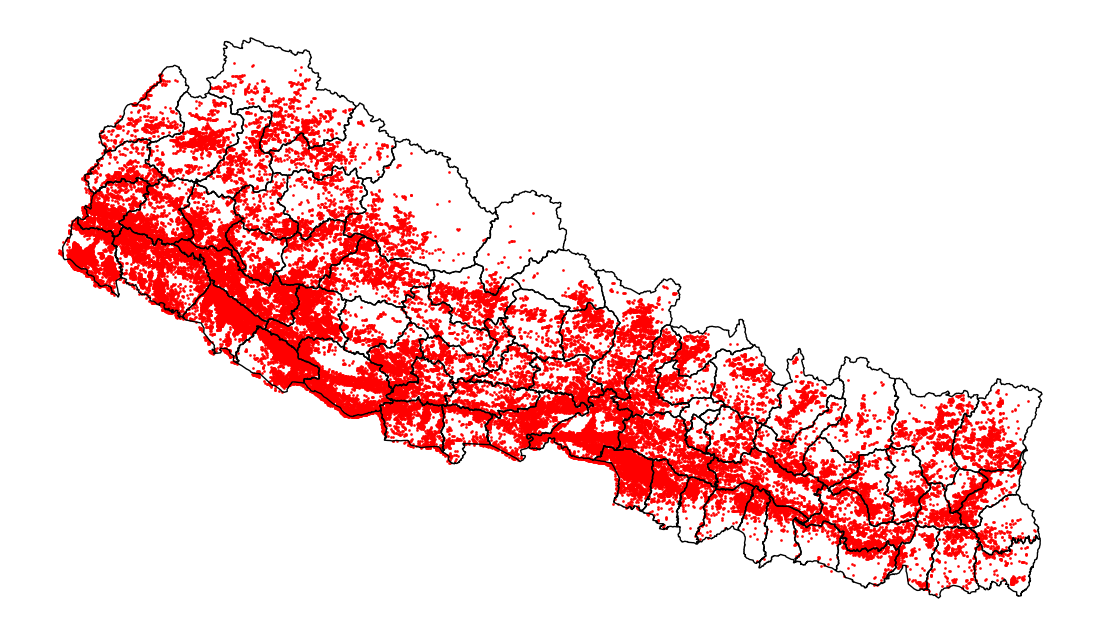

In [19]:
fig, ax = plt.subplots(figsize=(15, 8))

states.boundary.plot(ax = ax, color='black', linewidth=1)
wildfires.plot(ax = ax, color = 'red', markersize=1, alpha=0.9)


ax.set_axis_off()

plt.show()

In [20]:
fire_counts = (
  fire_with_state.groupby('STATE_CODE').
  size()
  .reset_index(name='FIRE_COUNT')
)

print(len(fire_counts))

fire_counts.head()

75


,STATE_CODE,FIRE_COUNT
0,NPL.1.1.1_1,6
1,NPL.1.1.2_1,1027
2,NPL.1.1.3_1,24
3,NPL.1.1.4_1,415
4,NPL.1.1.5_1,108


In [21]:
states_fire = states.merge(fire_counts, on='STATE_CODE', how='left')

states_fire.head()

,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry,FIRE_COUNT
0,NPL.1.1.1_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Bhaktapur,District,NP.MM.BK,"MULTIPOLYGON (((85.4064 27.63235, 85.3987 27.6...",6
1,NPL.1.1.2_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Dhading,District,NP.MM.DH,"MULTIPOLYGON (((84.90819 27.69722, 84.9026 27....",1027
2,NPL.1.1.3_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kathmandu,District,NP.MM.KT,"MULTIPOLYGON (((85.28735 27.58574, 85.28586 27...",24
3,NPL.1.1.4_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kavrepalanchok,District,NP.MM.KV,"MULTIPOLYGON (((85.69758 27.36454, 85.69907 27...",415
4,NPL.1.1.5_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Lalitpur,District,NP.MM.LL,"MULTIPOLYGON (((85.41771 27.43488, 85.41286 27...",108


In [22]:
states_fire.sort_values(['FIRE_COUNT'], ascending=False).reset_index().head(20)[['STATE_CODE', 'STATE_NAME', 'FIRE_COUNT']]

,STATE_CODE,STATE_NAME,FIRE_COUNT
0,NPL.1.3.2_1,Chitawan,4269
1,NPL.4.1.2_1,Bardiya,4260
2,NPL.4.1.5_1,Surkhet,3740
3,NPL.1.3.4_1,Parsa,3735
4,NPL.3.1.4_1,Kanchanpur,3375
5,NPL.3.2.5_1,Kailali,3238
6,NPL.4.3.1_1,Dang,3228
7,NPL.4.1.1_1,Banke,3053
8,NPL.4.3.5_1,Salyan,2441
9,NPL.5.3.4_1,Nawalparasi,2223


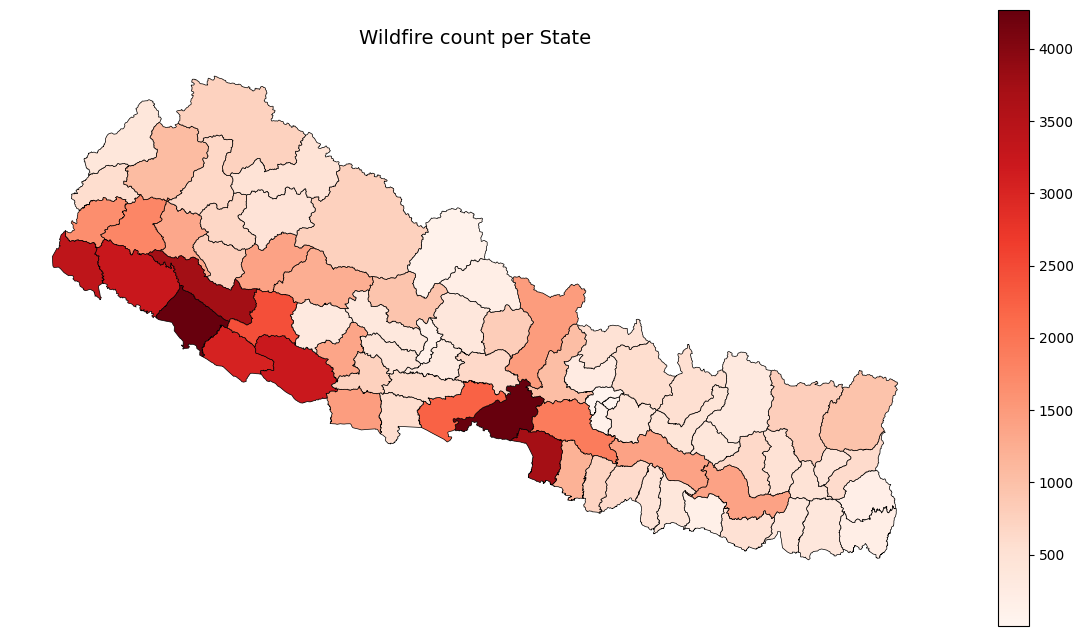

In [23]:
fig, ax = plt.subplots(figsize=(15, 8))

states_fire.plot(
  column='FIRE_COUNT',
  ax = ax,
  cmap='Reds',
  legend=True,
  edgecolor='black',
  linewidth=0.5
)

ax.set_axis_off()

plt.title('Wildfire count per State', fontsize=14)

plt.show()

In [24]:
nepal_centroid = states_fire.geometry.union_all().centroid

m = folium.Map(location=[nepal_centroid.y, nepal_centroid.x], zoom_start=7, tiles='cartodbpositron')

folium.Choropleth(
  geo_data=states_fire,
  data=states_fire,
  columns=['STATE_NAME', 'FIRE_COUNT'],
  key_on='feature.properties.STATE_NAME',
  fill_color="YlOrRd",
  fill_opacity=0.7,
  line_opacity=0.2,
  legend_name="Wildfire Count"
).add_to(m)

folium.GeoJson(
    states_fire,
    style_function=lambda x: {"fillColor": "transparent", "color": "black", "weight": 0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=["STATE_NAME", "FIRE_COUNT"],
        aliases=["State:", "Wildfire Count:"],
        localize=True
    )
).add_to(m)

m

# KDE plot

In [25]:
x = df.geometry.x
y = df.geometry.y

weights = df['FRP']

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


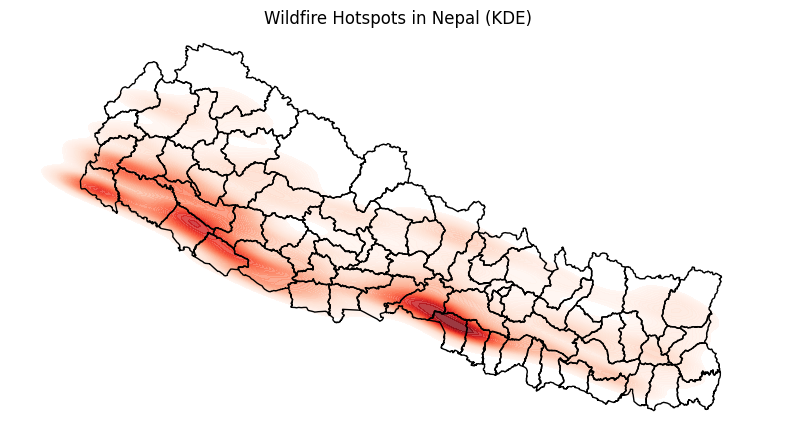

In [26]:
fig, ax = plt.subplots(figsize=(10,8))

sns.kdeplot(
  x=x, y=y,
  cmap='Reds',
  fill=True,
  bw_adjust=0.9,
  levels=60,
  alpha=0.8,
  ax=ax
)

states.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_axis_off()
ax.set_title('Wildfire Hotspots in Nepal (KDE)')

plt.show()

# Autocorrelation Test

In [27]:
states_fire.head()

,STATE_CODE,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry,FIRE_COUNT
0,NPL.1.1.1_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Bhaktapur,District,NP.MM.BK,"MULTIPOLYGON (((85.4064 27.63235, 85.3987 27.6...",6
1,NPL.1.1.2_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Dhading,District,NP.MM.DH,"MULTIPOLYGON (((84.90819 27.69722, 84.9026 27....",1027
2,NPL.1.1.3_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kathmandu,District,NP.MM.KT,"MULTIPOLYGON (((85.28735 27.58574, 85.28586 27...",24
3,NPL.1.1.4_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Kavrepalanchok,District,NP.MM.KV,"MULTIPOLYGON (((85.69758 27.36454, 85.69907 27...",415
4,NPL.1.1.5_1,NPL.1_1,Central,NPL.1.1_1,Bagmati,Lalitpur,District,NP.MM.LL,"MULTIPOLYGON (((85.41771 27.43488, 85.41286 27...",108


# Global Moran's I

In [28]:
y = states_fire['FIRE_COUNT'].astype(float).values

In [29]:
w = Queen.from_dataframe(states_fire)
w.transform = 'r'

/var/folders/mw/92tzvh5x7098x2prk2dnt57w0000gn/T/ipykernel_33554/869901836.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(states_fire)


In [30]:
moran = Moran(y, w)

print(f"Global Moran’s I: {moran.I:.3f}")
print(f"p-value: {moran.p_sim:.3f}")

Global Moran’s I: 0.553
p-value: 0.001


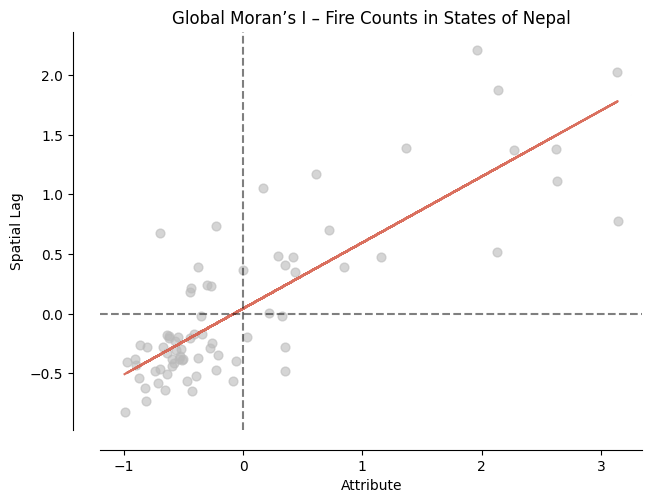

In [31]:
moran_scatterplot(moran)
plt.title("Global Moran’s I – Fire Counts in States of Nepal")
plt.show()

# local autocorrelation with Local Getis-Ord Gi*

In [32]:
g_local = G_Local(y, w)

states_fire['GiZ'] = g_local.Zs
states_fire['GiP'] = g_local.p_sim

states_fire['hotspot_class'] = 'Not Significant'
states_fire.loc[(states_fire["GiZ"] > 1.96) & (states_fire["GiP"] < 0.05), "hotspot_class"] = "Hot Spot"
states_fire.loc[(states_fire["GiZ"] < -1.96) & (states_fire["GiP"] < 0.05), "hotspot_class"] = "Cold Spot"

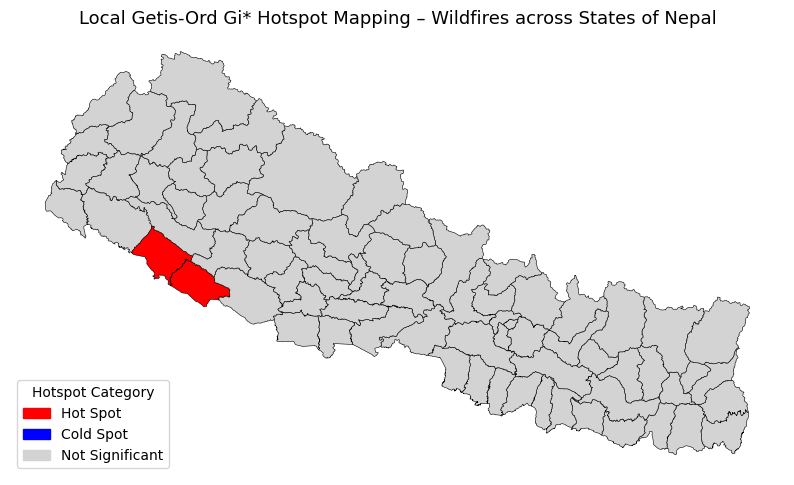

In [33]:
hotspot_colors = {
    "Hot Spot": "red",
    "Cold Spot": "blue",
    "Not Significant": "lightgrey"
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

states_fire.plot(
    color=states_fire["hotspot_class"].map(hotspot_colors),
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in hotspot_colors.items()
]
plt.legend(
    handles=legend_patches,
    title="Hotspot Category",
    loc="lower left",
    frameon=True,
    facecolor="white"
)

plt.title("Local Getis-Ord Gi* Hotspot Mapping – Wildfires across States of Nepal", fontsize=13)
plt.axis("off")
plt.show()
